In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

from scipy.stats import (
    norm,
    bernoulli,
    uniform,
    chisquare,
    kstest,
    entropy
)

# ============================================================
# Funciones auxiliares
# ============================================================

def kl_discrete(emp_probs, model_probs, eps=1e-12):
    emp_probs = np.asarray(emp_probs) + eps
    model_probs = np.asarray(model_probs) + eps

    emp_probs /= emp_probs.sum()
    model_probs /= model_probs.sum()

    return entropy(emp_probs, model_probs)

# Esta función aplica únicamente para distribucuones que son continuas
def analyze_continuous( 
        data,
        distribution_name,
        distribution,
        params,
        bins=20
):

    data = np.asarray(data)
    data = data[~np.isnan(data)]

    print("\n" + "=" * 70)
    print(distribution_name)
    print("=" * 70)

    print("La regla de decisión es:\n\n- Si p≥0.05: no rechazamos que los datos provengan de la distribución.\n- Si p<0.05: rechazamos que los datos provengan de la distribución.")
    # --------------------------------------------------
    # KS
    # --------------------------------------------------

    ks_stat, ks_p = kstest(
        data,
        distribution.cdf,
        args=params
    )

    print("\nKolmogorov-Smirnov")
    print(f"D = {ks_stat:.4f}")
    print(f"p-value = {ks_p:.6f}")

    # --------------------------------------------------
    # Gráfico
    # --------------------------------------------------

    x = np.linspace(
        data.min(),
        data.max(),
        500
    )

    plt.figure(figsize=(8,4))

    plt.hist(
        data,
        bins=bins,
        density=True,
        alpha=0.6,
        label="Empírica"
    )

    plt.plot(
        x,
        distribution.pdf(x, *params),
        lw=3,
        label="Modelo"
    )

    plt.title(distribution_name)
    plt.legend()
    plt.show()


def analyze_discrete(
    data,
    distribution_name,
    distribution,
    params,
    alpha=0.05,
    eps=1e-12
):
    """
    Analiza una distribución discreta cualquiera.

    Parámetros
    ----------
    data : array-like
        Muestra observada.

    distribution : scipy.stats.rv_discrete
        Distribución de scipy (poisson, binom, geom, nbinom, etc.)

    params : tuple
        Parámetros de la distribución.

    Retorna
    -------
    dict
        {
            "KL": ...,
            "chi2": ...,
            "pvalue": ...
        }
    """

    print("\n" + "="*70)
    print(distribution_name)
    print("="*70)
    print("La regla de decisión es:\n\n- Si p≥0.05: no rechazamos que los datos provengan de la distribución.\n- Si p<0.05: rechazamos que los datos provengan de la distribución.")
    
    data = np.asarray(data)

    N = len(data)

    # ---------------------------------------
    # soporte observado
    # ---------------------------------------

    observed = pd.Series(data).value_counts().sort_index()

    xmin = observed.index.min()
    xmax = observed.index.max()

    # ---------------------------------------
    # ampliar soporte teórico
    # ---------------------------------------

    lower = int(distribution.ppf(1e-8, *params))
    upper = int(distribution.ppf(1-1e-8, *params))

    lower = min(lower, xmin)
    upper = max(upper, xmax)

    support = np.arange(lower, upper+1)

    # ---------------------------------------
    # frecuencias empíricas
    # ---------------------------------------

    obs = observed.reindex(
        support,
        fill_value=0
    ).values

    emp_probs = obs / N

    # ---------------------------------------
    # probabilidades teóricas
    # ---------------------------------------

    model_probs = distribution.pmf(
        support,
        *params
    )

    model_probs = np.maximum(
        model_probs,
        eps
    )

    model_probs /= model_probs.sum()

    # ---------------------------------------
    # Divergencia KL
    # ---------------------------------------

    kl = kl_discrete(
        emp_probs,
        model_probs
    )

    print(f"KL = {kl:.8f}")

    # ---------------------------------------
    # Chi²
    # ---------------------------------------

    expected = model_probs * N

    mask = expected >= 5

    chi2 = np.sum(
        (obs[mask]-expected[mask])**2 /
        expected[mask]
    )

    # número de parámetros estimados
    k = len(params)

    df = mask.sum() - 1 - k

    if df <= 0:
        pvalue = np.nan
    else:
        pvalue = stats.chi2.sf(
            chi2,
            df
        )

    print("\nChi-cuadrado")
    print(f"Estadístico = {chi2:.6f}")
    print(f"gl = {df}")
    print(f"p-value = {pvalue:.6f}")





PARAMETROS NORMAL
mu = 29.69911764705882
sigma = 14.526497332334042

AJUSTE NORMAL - TITANIC AGE
KL = 0.068204

Chi-cuadrado
Estadístico = 112.3818
gl = 15
p-value = 0.000000
La regla de decisión es:

- Si p≥0.05: no rechazamos que los datos provengan de la distribución.
- Si p<0.05: rechazamos que los datos provengan de la distribución.

Kolmogorov-Smirnov
D = 0.0646
p-value = 0.004958


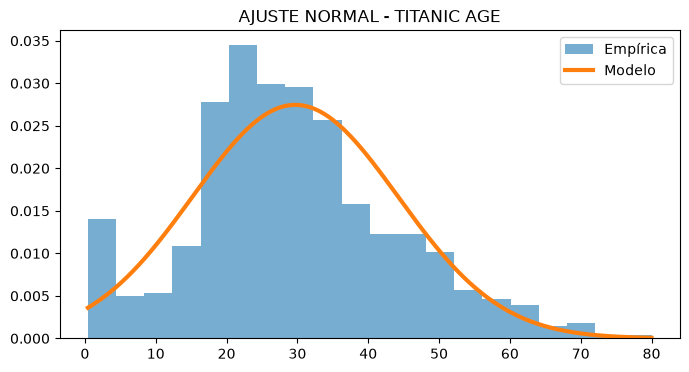

In [3]:
# ============================================================
# 1. NORMAL
# ============================================================

titanic = sns.load_dataset("titanic")

age = titanic["age"].dropna()


mu_hat = age.mean()
sigma_hat = age.std(ddof=1)

print("\nPARAMETROS NORMAL")
print("mu =", mu_hat)
print("sigma =", sigma_hat)

analyze_continuous(
    age,
    "AJUSTE NORMAL - TITANIC AGE",
    norm,
    (mu_hat, sigma_hat)
)




BINOMIAL / BERNOULLI
p estimado = 0.3838
[0.61616162 0.38383838] [0.61616162 0.38383838]
KL = 0.00000000

Chi-cuadrado
Estadístico = 0.000000
p-value = 1.000000

Kolmogorov-Smirnov
D = 0.616162
p-value = 0.000000


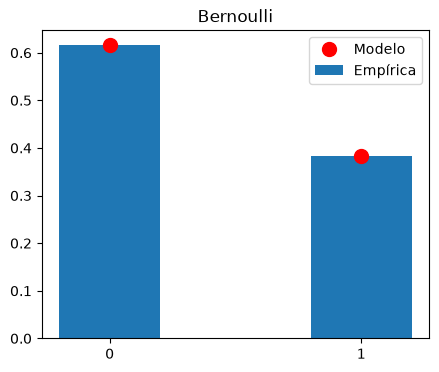

In [5]:
# ============================================================
# 2. BINOMIAL / BERNOULLI
# ============================================================

survived = titanic["survived"]

analyze_binomial(survived)




PARAMETROS UNIFORME
a = 4.3
b = 7.9

AJUSTE UNIFORME - IRIS SEPAL LENGTH
KL = 0.194259

Chi-cuadrado
Estadístico = 55.6000
gl = 17
p-value = 0.000005

Kolmogorov-Smirnov
D = 0.2000
p-value = 0.000010


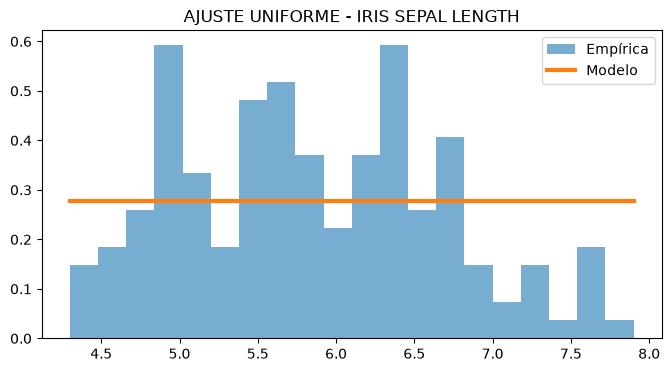

In [ ]:
# ============================================================
# 3. UNIFORME
# ============================================================

iris = sns.load_dataset("iris")

x = iris["sepal_length"].values

a_hat = x.min()
b_hat = x.max()

print("\nPARAMETROS UNIFORME")
print("a =", a_hat)
print("b =", b_hat)

analyze_continuous(
    x,
    "AJUSTE UNIFORME - IRIS SEPAL LENGTH",
    uniform,
    (a_hat, b_hat - a_hat)
)


PARAMETROS UNIFORME
a = 0.0010871855255782216
b = 6.282228797795947

AJUSTE UNIFORME - LANZAMIENTO DE DADO
KL = 0.000791

Chi-cuadrado
Estadístico = 15.8920
gl = 17
p-value = 0.531504

Kolmogorov-Smirnov
D = 0.0070
p-value = 0.703761


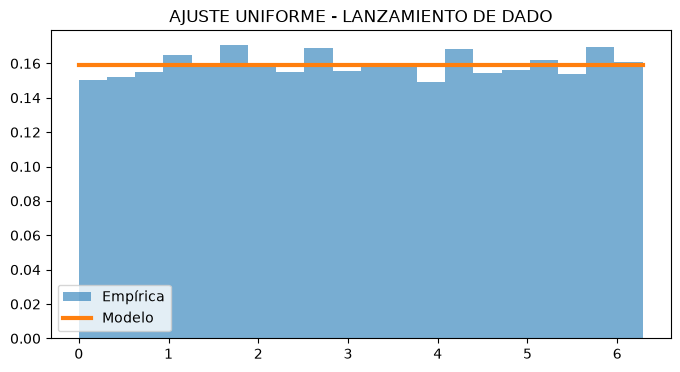

In [ ]:
x = np.random.uniform(low=0, high=2*np.pi, size=10000)
a_hat = x.min()
b_hat = x.max()

print("\nPARAMETROS UNIFORME")
print("a =", a_hat)
print("b =", b_hat)

analyze_continuous(
    x,
    "AJUSTE UNIFORME - LANZAMIENTO DE DADO",
    uniform,
    (a_hat, b_hat - a_hat)
)

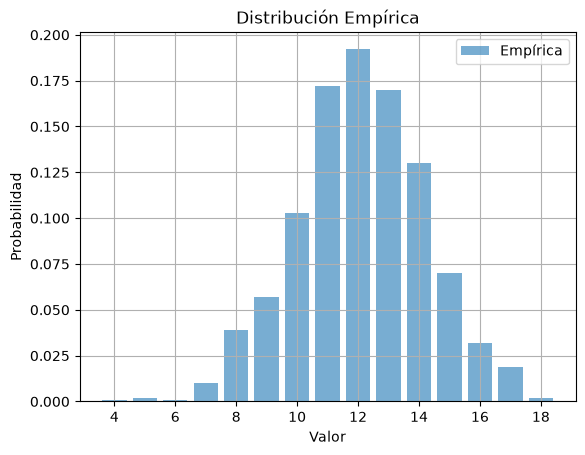

In [ ]:
x=[12 ,11 ,13 ,14 ,11 ,11 ,12 ,12 ,9 ,17 ,10 ,11 ,13 ,10 ,10 ,13 ,8 ,14 ,12 ,11 ,12 ,13 ,16 ,12 ,14 ,10 ,11 ,10 ,10 ,8 ,15 ,11 ,9 ,15 ,10 ,4 ,11 ,12 ,14 ,15 ,12 ,14 ,10 ,10 ,11 ,14 ,14 ,9 ,13 ,13 ,14 ,14 ,12 ,12 ,8 ,11 ,13 ,11 ,11 ,15 ,11 ,16 ,10 ,11 ,13 ,13 ,14 ,11 ,11 ,12 ,15 ,11 ,17 ,13 ,10 ,13 ,12 ,13 ,13 ,14 ,15 ,14 ,9 ,10 ,13 ,9 ,10 ,11 ,13 ,10 ,14 ,13 ,14 ,12 ,11 ,11 ,11 ,13 ,12 ,11 ,12 ,9 ,11 ,10 ,14 ,12 ,10 ,15 ,10 ,14 ,13 ,16 ,11 ,14 ,12 ,10 ,8 ,13 ,12 ,11 ,17 ,13 ,15 ,8 ,10 ,12 ,11 ,11 ,13 ,11 ,8 ,11 ,12 ,10 ,11 ,13 ,13 ,9 ,16 ,10 ,14 ,13 ,10 ,9 ,11 ,15 ,8 ,12 ,12 ,13 ,11 ,11 ,13 ,14 ,11 ,14 ,14 ,13 ,13 ,11 ,17 ,12 ,10 ,12 ,13 ,10 ,13 ,11 ,12 ,13 ,12 ,12 ,11 ,6 ,11 ,13 ,10 ,11 ,13 ,11 ,11 ,12 ,13 ,12 ,8 ,12 ,11 ,12 ,12 ,14 ,11 ,12 ,15 ,12 ,10 ,8 ,12 ,15 ,13 ,12 ,14 ,17 ,11 ,17 ,14 ,13 ,13 ,12 ,11 ,16 ,10 ,12 ,11 ,14 ,12 ,12 ,8 ,14 ,11 ,13 ,15 ,11 ,13 ,9 ,11 ,13 ,11 ,11 ,11 ,9 ,13 ,11 ,12 ,14 ,12 ,7 ,12 ,13 ,9 ,16 ,12 ,11 ,7 ,12 ,11 ,12 ,11 ,12 ,13 ,12 ,13 ,14 ,14 ,13 ,13 ,12 ,14 ,12 ,13 ,15 ,15 ,17 ,13 ,14 ,10 ,11 ,12 ,9 ,11 ,13 ,16 ,12 ,13 ,10 ,12 ,11 ,13 ,9 ,12 ,14 ,14 ,11 ,13 ,13 ,14 ,11 ,11 ,12 ,13 ,12 ,16 ,15 ,8 ,16 ,8 ,9 ,9 ,10 ,11 ,14 ,11 ,12 ,9 ,13 ,12 ,13 ,14 ,14 ,12 ,12 ,14 ,12 ,11 ,13 ,14 ,12 ,12 ,13 ,10 ,11 ,14 ,12 ,14 ,14 ,9 ,14 ,8 ,11 ,11 ,8 ,14 ,14 ,12 ,8 ,13 ,15 ,15 ,16 ,10 ,13 ,14 ,12 ,14 ,10 ,12 ,10 ,11 ,17 ,12 ,17 ,11 ,11 ,12 ,13 ,13 ,9 ,14 ,13 ,16 ,12 ,11 ,12 ,12 ,16 ,8 ,10 ,10 ,10 ,14 ,12 ,13 ,10 ,9 ,9 ,16 ,12 ,11 ,12 ,13 ,17 ,10 ,8 ,11 ,14 ,8 ,10 ,10 ,9 ,12 ,15 ,12 ,13 ,12 ,12 ,11 ,12 ,8 ,11 ,14 ,9 ,11 ,7 ,9 ,9 ,9 ,10 ,14 ,12 ,13 ,10 ,15 ,13 ,11 ,11 ,11 ,15 ,18 ,9 ,12 ,7 ,16 ,12 ,12 ,11 ,14 ,12 ,13 ,14 ,14 ,9 ,12 ,17 ,11 ,13 ,13 ,14 ,9 ,11 ,13 ,12 ,11 ,17 ,11 ,14 ,12 ,12 ,14 ,12 ,12 ,13 ,13 ,13 ,12 ,10 ,12 ,13 ,11 ,12 ,11 ,11 ,12 ,9 ,12 ,12 ,12 ,12 ,10 ,13 ,11 ,13 ,13 ,12 ,13 ,15 ,10 ,12 ,14 ,16 ,17 ,9 ,17 ,14 ,11 ,11 ,11 ,12 ,14 ,8 ,10 ,15 ,10 ,11 ,14 ,15 ,10 ,13 ,14 ,11 ,11 ,12 ,11 ,12 ,13 ,15 ,12 ,9 ,9 ,13 ,12 ,11 ,8 ,14 ,14 ,13 ,11 ,12 ,12 ,15 ,9 ,14 ,12 ,10 ,12 ,14 ,14 ,12 ,10 ,8 ,10 ,12 ,11 ,11 ,10 ,14 ,15 ,13 ,13 ,11 ,15 ,15 ,8 ,11 ,10 ,13 ,14 ,13 ,9 ,12 ,11 ,14 ,10 ,12 ,11 ,12 ,10 ,11 ,15 ,10 ,14 ,17 ,13 ,13 ,12 ,13 ,9 ,8 ,12 ,17 ,12 ,13 ,11 ,11 ,10 ,12 ,12 ,11 ,14 ,15 ,12 ,9 ,15 ,9 ,13 ,14 ,8 ,12 ,15 ,10 ,8 ,14 ,13 ,11 ,17 ,15 ,12 ,15 ,11 ,15 ,14 ,11 ,10 ,15 ,13 ,14 ,15 ,16 ,14 ,8 ,10 ,13 ,15 ,12 ,12 ,10 ,18 ,11 ,13 ,14 ,8 ,11 ,9 ,13 ,16 ,13 ,11 ,10 ,12 ,11 ,14 ,15 ,13 ,13 ,10 ,15 ,13 ,9 ,13 ,11 ,14 ,9 ,12 ,13 ,10 ,5 ,15 ,11 ,16 ,10 ,7 ,13 ,14 ,13 ,11 ,12 ,12 ,11 ,13 ,12 ,12 ,11 ,11 ,14 ,13 ,15 ,15 ,10 ,11 ,15 ,14 ,11 ,12 ,12 ,11 ,14 ,12 ,13 ,13 ,12 ,12 ,14 ,15 ,11 ,13 ,14 ,12 ,12 ,14 ,15 ,11 ,15 ,13 ,9 ,13 ,12 ,11 ,14 ,11 ,11 ,12 ,16 ,11 ,9 ,14 ,13 ,10 ,12 ,13 ,12 ,11 ,11 ,13 ,13 ,13 ,9 ,8 ,14 ,14 ,13 ,13 ,11 ,13 ,13 ,12 ,13 ,16 ,12 ,10 ,12 ,8 ,9 ,11 ,8 ,11 ,9 ,13 ,13 ,15 ,10 ,12 ,12 ,12 ,14 ,13 ,14 ,11 ,16 ,15 ,12 ,13 ,11 ,12 ,12 ,13 ,12 ,16 ,14 ,9 ,11 ,10 ,13 ,13 ,10 ,14 ,14 ,14 ,11 ,15 ,13 ,10 ,15 ,14 ,12 ,14 ,11 ,14 ,14 ,13 ,13 ,16 ,10 ,10 ,11 ,15 ,14 ,15 ,12 ,10 ,13 ,11 ,15 ,17 ,12 ,11 ,13 ,11 ,14 ,9 ,11 ,9 ,12 ,15 ,12 ,11 ,13 ,13 ,10 ,12 ,12 ,10 ,12 ,12 ,13 ,11 ,11 ,13 ,10 ,13 ,5 ,15 ,15 ,12 ,9 ,14 ,10 ,8 ,12 ,12 ,16 ,15 ,16 ,12 ,15 ,16 ,15 ,14 ,12 ,10 ,12 ,13 ,11 ,15 ,16 ,9 ,13 ,14 ,12 ,12 ,14 ,14 ,11 ,10 ,17 ,11 ,13 ,13 ,13 ,9 ,14 ,13 ,13 ,11 ,14 ,14 ,11 ,9 ,14 ,7 ,11 ,13 ,14 ,11 ,14 ,11 ,8 ,11 ,13 ,10 ,13 ,10 ,13 ,13 ,11 ,11 ,16 ,15 ,15 ,11 ,10 ,12 ,10 ,12 ,10 ,14 ,11 ,16 ,10 ,14 ,10 ,11 ,8 ,10 ,10 ,14 ,12 ,15 ,12 ,12 ,12 ,13 ,13 ,10 ,13 ,13 ,11 ,7 ,11 ,10 ,11 ,7 ,14 ,13 ,13 ,12 ,12 ,11 ,7 ,12 ,10 ,14 ,11 ,15 ,15 ,14 ,13 ,14 ,13 ,9 ,10 ,12 ,13 ,13 ,14 ,11 ,10 ,15 ,15 ,10 ,12 ,12 ,13 ,9 ,8 ,10 ,14 ,13 ,12 ,14 ,15 ,8 ,16 ,12 ,11 ,11 ,13 ,8 ,11 ,14 ,10 ,9 ,13 ,10 ,10 ,12 ,10 ,7 ,16 ,15 ,14 ,12 ,13 ,8 ,13 ,14 ,14 ,9 ,13 ,16 ,8 ,12 ,11 ,12 ,12 ,9 ,10 ,14 ,12 ,12 ,12 ,13 ,12]
xi, ni=np.unique(x, return_counts=True)
plt.bar(xi, ni/len(x), width=0.8, alpha=0.6, label="Empírica")
plt.xlabel("Valor")
plt.ylabel("Probabilidad")
plt.title("Distribución Empírica")
plt.legend()
plt.grid()
plt.show()


BINOMIAL / BERNOULLI
n estimado/usado = 18
p estimado = 0.6718

Probabilidades modelo:
[1.95444596e-09 7.20035360e-08 1.25265190e-06 1.36737231e-05
 1.04948371e-04 6.01438721e-04 2.66711130e-03 9.35797750e-03
 2.63355472e-02 5.98904380e-02 1.10320863e-01 1.64214917e-01
 1.96059120e-01 1.85204954e-01 1.35379286e-01 7.38887985e-02
 2.83555143e-02 6.82772867e-03 7.76356871e-04]

Probabilidades empíricas:
[0.    0.    0.    0.    0.001 0.002 0.001 0.01  0.039 0.057 0.103 0.172
 0.192 0.17  0.13  0.07  0.032 0.019 0.002]

KL = 0.01529982

Chi-cuadrado
Estadístico = 44.919424
gl = 17
p-value = 0.000250

Kolmogorov-Smirnov
D = 0.184567
p-value = 0.000000


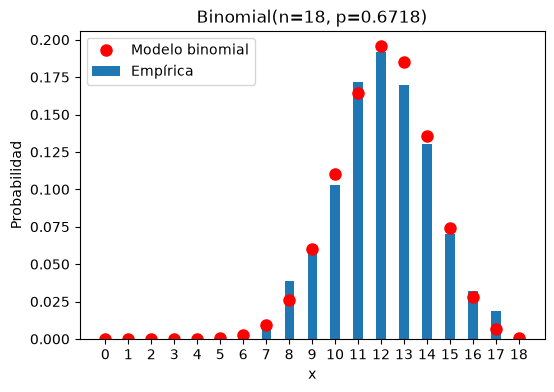

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import binom, kstest


def analyze_binomial(data, n=None):

    print("\n" + "=" * 70)
    print("BINOMIAL / BERNOULLI")
    print("=" * 70)

    data = np.asarray(data)

    N = len(data)

    if n is None:
        n = int(data.max())

    if n <= 0:
        raise ValueError("n debe ser mayor que 0.")

    if np.any(data < 0) or np.any(data > n):
        raise ValueError("Los datos deben estar entre 0 y n.")

    if not np.all(data == np.floor(data)):
        raise ValueError("La distribución binomial requiere valores enteros.")

    # --------------------------------------------------
    # Estimación de p
    # --------------------------------------------------

    p_hat = data.mean() / n

    print(f"n estimado/usado = {n}")
    print(f"p estimado = {p_hat:.4f}")

    # --------------------------------------------------
    # Probabilidad empírica
    # --------------------------------------------------

    x_values = np.arange(0, n + 1)

    counts = (
        pd.Series(data)
        .value_counts()
        .reindex(x_values, fill_value=0)
        .sort_index()
    )

    obs = counts.values
    emp_probs = obs / obs.sum()

    # --------------------------------------------------
    # Probabilidad teórica binomial
    # --------------------------------------------------

    model_probs = binom.pmf(x_values, n, p_hat)

    print("\nProbabilidades modelo:")
    print(model_probs)

    print("\nProbabilidades empíricas:")
    print(emp_probs)

    # --------------------------------------------------
    # KL
    # --------------------------------------------------

    kl = kl_discrete(
        emp_probs,
        model_probs
    )

    print(f"\nKL = {kl:.8f}")

    # --------------------------------------------------
    # Chi-cuadrado
    # --------------------------------------------------

    expected = model_probs * N

    mask = expected > 0

    chi2_stat = np.sum(
        (obs[mask] - expected[mask])**2 / expected[mask]
    )

    # Se estima p, entonces se resta 1 parámetro.
    # Categorías efectivas - 1 - parámetros estimados
    df = mask.sum() - 1 - 1

    if df > 0:
        p_value = 1 - stats.chi2.cdf(
            chi2_stat,
            df
        )
    else:
        p_value = np.nan

    print("\nChi-cuadrado")
    print(f"Estadístico = {chi2_stat:.6f}")
    print(f"gl = {df}")
    print(f"p-value = {p_value:.6f}")

    # --------------------------------------------------
    # KS
    # --------------------------------------------------

    ks_stat, ks_p = kstest(
        data,
        binom(n, p_hat).cdf
    )

    print("\nKolmogorov-Smirnov")
    print(f"D = {ks_stat:.6f}")
    print(f"p-value = {ks_p:.6f}")

    # --------------------------------------------------
    # Gráfico
    # --------------------------------------------------

    plt.figure(figsize=(6, 4))

    plt.bar(
        x_values,
        emp_probs,
        width=0.4,
        label="Empírica"
    )

    plt.plot(
        x_values,
        model_probs,
        "ro",
        markersize=8,
        label="Modelo binomial"
    )

    plt.xticks(x_values)
    plt.legend()
    plt.title(f"Binomial(n={n}, p={p_hat:.4f})")
    plt.xlabel("x")
    plt.ylabel("Probabilidad")
    plt.show()

analyze_binomial(x)